In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
merged_df = pd.read_csv("merged_results.csv")

# Valid DMARC

In [8]:
valid_dmarc = merged_df["dmarc_valid"].mean() * 100
print(f"Percent of records with valid DMARC: {valid_dmarc:.2f}%")

Percent of records with valid DMARC: 44.19%


# Valid records by ranking tier

      ranking_tier_x  pct_all_three_valid
0      Tier 1 (1-1K)            43.200000
1    Tier 2 (1K-10K)            40.455556
2  Tier 3 (10K-100K)            30.976667
3   Tier 4 (100K-1M)             0.008556


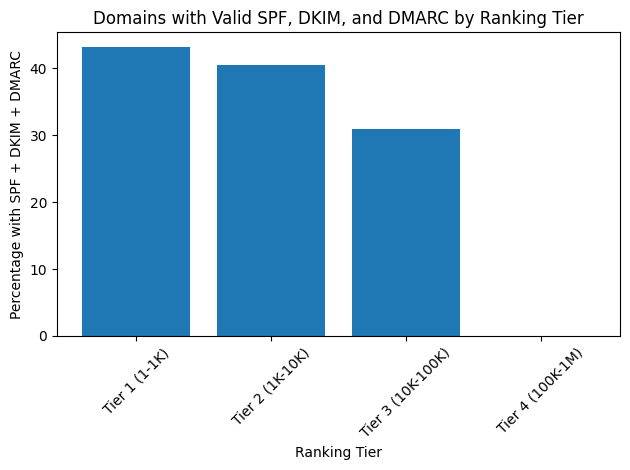

In [5]:
valid_all = (
    merged_df[(merged_df["dkim_present"]) & 
              (merged_df["dmarc_valid"]) & 
              (merged_df["spf_present"])]
    .groupby("ranking_tier_x")
    .size()
)

total = merged_df.groupby("ranking_tier_x").size()

percentage = (valid_all / total * 100).reset_index(name="pct_all_three_valid")
percentage = percentage.sort_values("ranking_tier_x")
print(percentage)

plt.figure()
plt.bar(percentage["ranking_tier_x"], percentage["pct_all_three_valid"])
plt.xlabel("Ranking Tier")
plt.ylabel("Percentage with SPF + DKIM + DMARC")
plt.title("Domains with Valid SPF, DKIM, and DMARC by Ranking Tier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()